In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
np.random.seed(42)

# Task 1: Create the Dataset 

In [3]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

print("XOR Dataset")
print("X (Inputs):\n", X)
print("y (Targets):\n", y)

XOR Dataset
X (Inputs):
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y (Targets):
 [[0.]
 [1.]
 [1.]
 [0.]]


In [4]:
def plot_decision_boundary(predict_func, title="Decision Boundary"):
    """Plots the 2D decision boundary for any classification prediction function."""
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    preds = predict_func(grid_points)
    preds = preds.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, preds, levels=20, cmap="coolwarm", alpha=0.8)
    plt.colorbar(label="Output Probability")

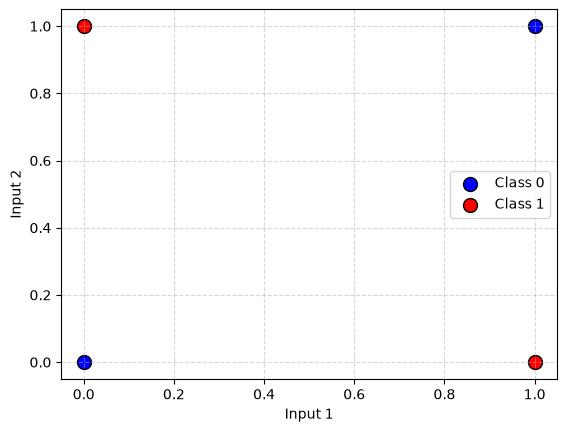

In [5]:
plt.scatter(
        X[y.ravel() == 0, 0],
        X[y.ravel() == 0, 1],
        color="blue",
        s=100,
        edgecolor="k",
        label="Class 0",
    )
plt.scatter(
        X[y.ravel() == 1, 0],
        X[y.ravel() == 1, 1],
        color="red",
        s=100,
        edgecolor="k",
        label="Class 1",
    )

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# IMPLEMENTATION 1: KERAS (TensorFlow High-Level API)

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

tf.random.set_seed(42)

# 1. Build Model

In [7]:
keras_model = Sequential(
    [
        Dense(4, activation="relu", input_shape=(2,)),  # Hidden layer (4 neurons)
        Dense(1, activation="sigmoid"),  # Output layer (1 neuron)
    ]
)

e:\CLG\ML\lab\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 2. Compile Model

In [8]:
keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# 3. Train Model

In [9]:
history_keras = keras_model.fit(X, y, epochs=500, verbose=0)

# 4. Evaluate & Predict

In [10]:
keras_preds = keras_model.predict(X, verbose=0)
print("Keras Results")
for i in range(len(X)):
    print(
        f"Input: {X[i]} -> Target: {int(y[i][0])} | Predicted Prob: {keras_preds[i][0]:.4f} | Binary Class: {int(keras_preds[i][0] >= 0.5)}"
    )

Keras Results
Input: [0. 0.] -> Target: 0 | Predicted Prob: 0.0022 | Binary Class: 0
Input: [0. 1.] -> Target: 1 | Predicted Prob: 0.9996 | Binary Class: 1
Input: [1. 0.] -> Target: 1 | Predicted Prob: 0.9996 | Binary Class: 1
Input: [1. 1.] -> Target: 0 | Predicted Prob: 0.0022 | Binary Class: 0


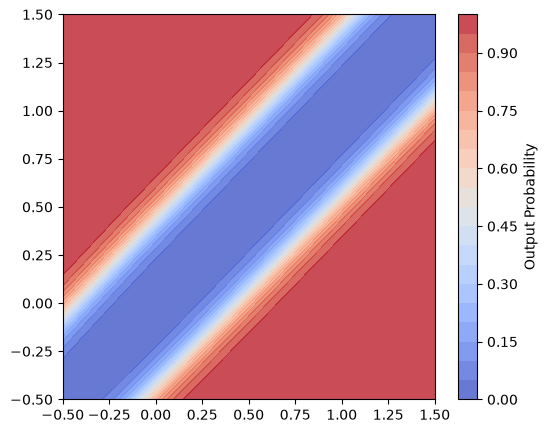

In [11]:
plot_decision_boundary(
    lambda grid: keras_model.predict(grid, verbose=0),
    title="Keras MLP Decision Boundary",
)

# IMPLEMENTATION 2: PYTORCH

In [12]:
import sys

for module_name in list(sys.modules):
    if module_name == "torch" or module_name.startswith("torch."):
        del sys.modules[module_name]

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

# 1. Build Model

In [13]:
class XORPyTorchModel(nn.Module):

    def __init__(self):
        super(XORPyTorchModel, self).__init__()
        self.hidden = nn.Linear(2, 4)  # 2 inputs -> 4 hidden neurons
        self.relu = nn.ReLU()
        self.output = nn.Linear(4, 1)  # 4 hidden -> 1 output
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x


pytorch_model = XORPyTorchModel()

# 2. Define Loss & Optimizer

In [14]:
criterion = nn.BCELoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.05)

In [15]:
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

# 3. Train Model

In [16]:
loss_history_pytorch = []
epochs = 500

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = pytorch_model(X_torch)
    loss = criterion(predictions, y_torch)
    loss.backward()
    optimizer.step()
    loss_history_pytorch.append(loss.item())

# 4. Evaluate & Predict

In [17]:
pytorch_model.eval()
with torch.no_grad():
    pytorch_preds = pytorch_model(X_torch).numpy()

print("PyTorch Results")
for i in range(len(X)):
    print(
        f"Input: {X[i]} -> Target: {int(y[i][0])} | Predicted Prob: {pytorch_preds[i][0]:.4f} | Binary Class: {int(pytorch_preds[i][0] >= 0.5)}"
    )

PyTorch Results
Input: [0. 0.] -> Target: 0 | Predicted Prob: 0.0005 | Binary Class: 0
Input: [0. 1.] -> Target: 1 | Predicted Prob: 0.9995 | Binary Class: 1
Input: [1. 0.] -> Target: 1 | Predicted Prob: 0.9937 | Binary Class: 1
Input: [1. 1.] -> Target: 0 | Predicted Prob: 0.0006 | Binary Class: 0


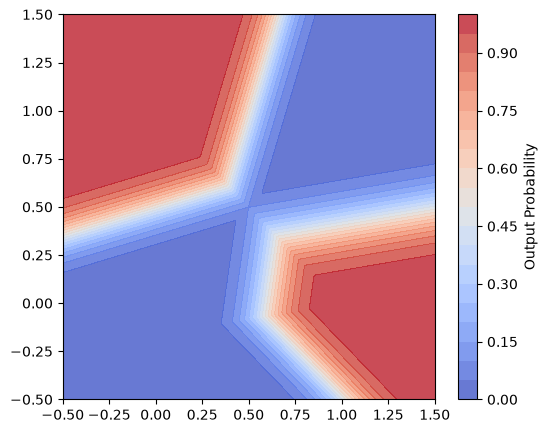

In [18]:
def pytorch_predict_grid(grid):
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    with torch.no_grad():
        return pytorch_model(grid_tensor).numpy()


plot_decision_boundary(
    pytorch_predict_grid, title="PyTorch MLP Decision Boundary"
)

# IMPLEMENTATION 3: TENSORFLOW LOW-LEVEL API

In [19]:
import tensorflow as tf

tf.random.set_seed(42)

# 1. Define Trainable Parameters

In [20]:
W1 = tf.Variable(
    tf.random.normal([2, 4], stddev=0.5), dtype=tf.float32, name="W1"
)
b1 = tf.Variable(tf.zeros([4]), dtype=tf.float32, name="b1")
W2 = tf.Variable(
    tf.random.normal([4, 1], stddev=0.5), dtype=tf.float32, name="W2"
)
b2 = tf.Variable(tf.zeros([1]), dtype=tf.float32, name="b2")

# 2. Forward Pass Model Definition

In [21]:
def tf_low_level_model(X_in):
    h = tf.nn.relu(tf.matmul(X_in, W1) + b1)
    out = tf.nn.sigmoid(tf.matmul(h, W2) + b2)
    return out

# 3. Training Loop

In [22]:
optimizer_tf = tf.optimizers.Adam(learning_rate=0.05)
loss_history_tf = []

for epoch in range(500):
    with tf.GradientTape() as tape:
        preds = tf_low_level_model(X)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, preds))

    grads = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer_tf.apply_gradients(zip(grads, [W1, b1, W2, b2]))
    loss_history_tf.append(loss.numpy())

# 4. Evaluate & Predict

In [23]:
tf_preds = tf_low_level_model(X).numpy()

print(" TensorFlow Low-Level Results ")
for i in range(len(X)):
    print(
        f"Input: {X[i]} -> Target: {int(y[i][0])} | Predicted Prob: {tf_preds[i][0]:.4f} | Binary Class: {int(tf_preds[i][0] >= 0.5)}"
    )

 TensorFlow Low-Level Results 
Input: [0. 0.] -> Target: 0 | Predicted Prob: 0.0013 | Binary Class: 0
Input: [0. 1.] -> Target: 1 | Predicted Prob: 0.9995 | Binary Class: 1
Input: [1. 0.] -> Target: 1 | Predicted Prob: 0.9998 | Binary Class: 1
Input: [1. 1.] -> Target: 0 | Predicted Prob: 0.0013 | Binary Class: 0


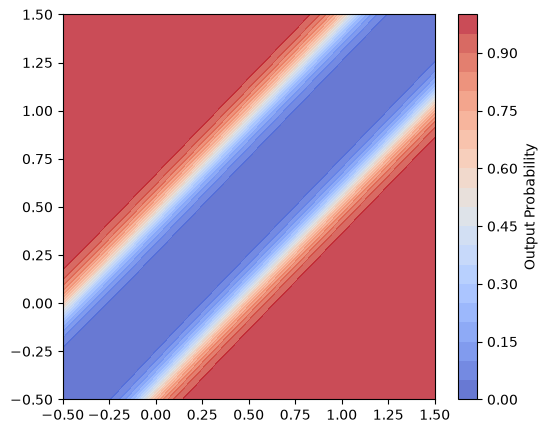

In [24]:
plot_decision_boundary(
    lambda grid: tf_low_level_model(tf.constant(grid, dtype=tf.float32)).numpy(),
    title="TensorFlow Low-Level MLP Decision Boundary",
)

# COMPARISON OF TRAINING CURVES Across LIBRARIES

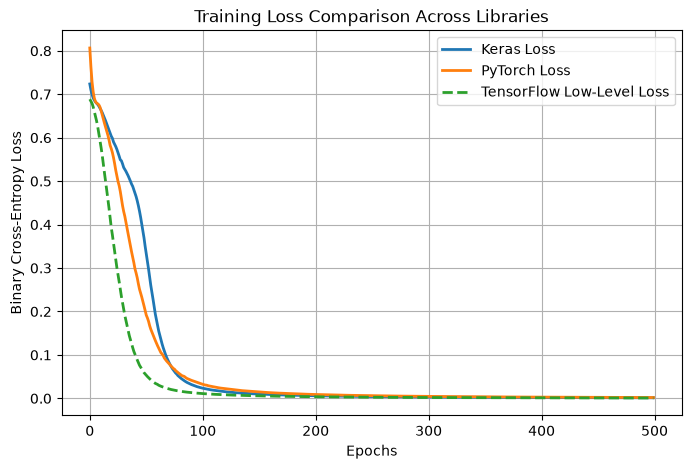

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history_keras.history["loss"], label="Keras Loss", linewidth=2)
plt.plot(loss_history_pytorch, label="PyTorch Loss", linewidth=2)
plt.plot(
    loss_history_tf,
    label="TensorFlow Low-Level Loss",
    linewidth=2,
    linestyle="--",
)
plt.title("Training Loss Comparison Across Libraries")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()